# **EXPERIMENT NO. :- 4**

Name :- Abhijeet Dinakar Pathade

Roll_No :- 16

Division :- TY-A(AIML)


## Logistic Regression for Binary Classification:

## Objective
To implement Logistic Regression for a binary classification problem (Purchased / Not Purchased)
using Age and EstimatedSalary as input features.


## Step 1: Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc


## Step 2: Load Dataset

In [ ]:
# Load the Purchased dataset from the specified file path into a Pandas DataFrame
df = pd.read_csv("/content/drive/MyDrive/Social_Network_Ads.csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Display the first five rows of the DataFrame to quickly inspect the data
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [ ]:
# Display concise information about the DataFrame such as column names, data types, and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [ ]:
# Check for missing (null) values in each column of the DataFrame
df.isnull().sum()

,0
Age,0
EstimatedSalary,0
Purchased,0


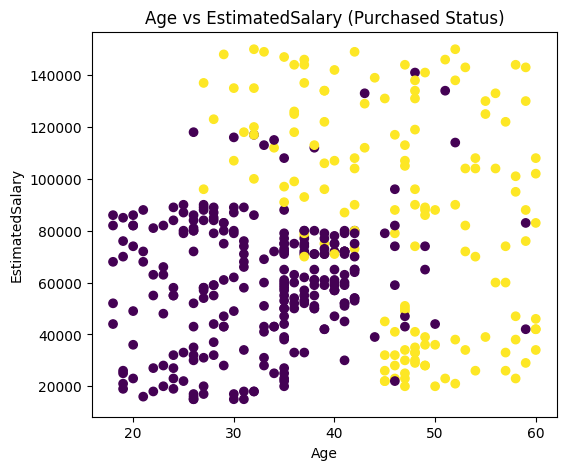

In [ ]:
# Create a scatter plot of Age vs EstimatedSalary
# Color points based on Purchased status (0 = Not Purchased, 1 = Purchased)

plt.figure(figsize=(6, 5))
plt.scatter(df['Age'], df['EstimatedSalary'], c=df['Purchased'])
plt.xlabel('Age')
plt.ylabel('EstimatedSalary')
plt.title('Age vs EstimatedSalary (Purchased Status)')
plt.show()


## Step 4: Feature Selection

In [ ]:
# Select the independent variables (features): Age and EstimatedSalary
X = df[['Age', 'EstimatedSalary']]

# Select the dependent variable (target): Purchased status (1 = Purchased, 0 = Not Purchased)
y = df['Purchased']


## Step 5: Train-Test Split

In [ ]:
# Split the dataset into training and testing sets
# 80% data is used for training and 20% for testing
# stratify=y ensures both classes are equally represented in train and test sets
# random_state ensures the same split every time the code is executed
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Step 6: Feature Scaling

In [ ]:
# Create a StandardScaler object to normalize the feature values
scaler = StandardScaler()

# Fit the scaler on training data and transform it
# This standardizes features to have mean = 0 and standard deviation = 1
X_train = scaler.fit_transform(X_train)

# Transform the test data using the same scaler
# (Important: do NOT fit again on test data)
X_test = scaler.transform(X_test)

## Step 7: Model Training

In [ ]:
# Create an object of the Logistic Regression model
model = LogisticRegression()


In [ ]:
# Train (fit) the model using the training data
# The model learns the relationship between Age, EstimatedSalary and placement outcome
model.fit(X_train, y_train)

LogisticRegression()

## Step 8: Predictions

In [ ]:
# Predict the placement outcome for the test dataset using the trained model
y_pred = model.predict(X_test)

## Step 9: Model Evaluation

In [ ]:
# Display the accuracy of the model
# Accuracy shows the percentage of correctly classified instances
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8375


In [ ]:
# Display the confusion matrix
# It shows counts of True Positives, True Negatives, False Positives, and False Negatives
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[48  3]
 [10 19]]


In [ ]:
# Display the classification report
# It includes precision, recall, F1-score, and support for each class
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.94      0.88        51
           1       0.86      0.66      0.75        29

    accuracy                           0.84        80
   macro avg       0.85      0.80      0.81        80
weighted avg       0.84      0.84      0.83        80



## Step 10: ROC Curve

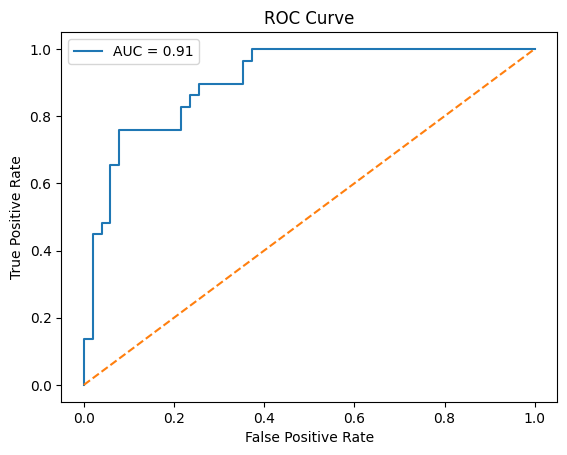

In [ ]:
# Predict the probability of the positive class (Purchased = 1) for the test data
# [:, 1] selects the probability of class '1'
y_prob = model.predict_proba(X_test)[:, 1]

# Compute False Positive Rate (FPR) and True Positive Rate (TPR) for different thresholds
fpr, tpr, _ = roc_curve(y_test, y_prob)

# Calculate Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.plot(fpr, tpr, label='AUC = %.2f' % roc_auc)

# Plot the diagonal reference line (random classifier)
plt.plot([0, 1], [0, 1], linestyle='--')

# Label the axes
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

# Set the title of the plot
plt.title('ROC Curve')

# Display legend
plt.legend()

# Show the plot
plt.show()


## Step 11: Prediction for New Data

In [ ]:
# Create a new data point for a student with Age = 7.8 and EstimatedSalary = 120
new_customer = np.array([[30, 90000]])

# Apply the same scaling used for training data
new_customer_scaled = scaler.transform(new_customer)

# Predict the placement outcome for the new student
prediction = model.predict(new_customer_scaled)

# Display the prediction result in a readable format
print("Prediction:", "Purchased" if prediction[0] == 1 else "Not Purchased")

Prediction: Not Purchased


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# Take input values from the user
age = float(input("Enter Age: "))
salary = float(input("Enter Salary: "))

# Create input array in required 2D format
new_customer = np.array([[age, salary]])

# Apply the same scaling used during model training
new_customer_scaled = scaler.transform(new_customer)

# Predict the placement outcome for the given input
prediction = model.predict(new_customer_scaled)

# Display the prediction result in a user-friendly format
print("Prediction:", "Purchased" if prediction[0] == 1 else "Not Purchased")

Enter Age: 30
Enter Salary: 20000
Prediction: Not Purchased


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
import pickle

In [ ]:
from sklearn.pipeline import Pipeline

final_model = Pipeline([
    ("scaler", scaler),
    ("model", model)
])

pickle.dump(final_model, open("BCModel.pkl", "wb"))

**Flask Code**

save this file as 'app.py'

In [ ]:
from flask import Flask, render_template, request
import pickle
import numpy as np

app = Flask(__name__)

# Load Trained Logistic Regression Model
model = pickle.load(open("BCModel.pkl", "rb"))


@app.route('/')
def home():
    return render_template("index.html")


@app.route('/predict', methods=['POST'])
def predict():

    # Read user inputs
    age = float(request.form['age'])
    salary = float(request.form['salary'])

    # Prediction
    prediction = model.predict(np.array([[age, salary]]))

    # Convert numeric prediction to text
    if prediction[0] == 1:
        result = "Customer is Likely to be Purchased"
    else:
        result = "Customer is NOT Likely to be Purchased"

    return render_template(
        "index.html",
        prediction_text=result
    )


if __name__ == "__main__":
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)


**HTML Code**

Save this file as 'index.html'

In [ ]:
<!DOCTYPE html>
<html lang="en">

<head>

<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">

<title>Placement Prediction</title>

<style>

*{
    margin:0;
    padding:0;
    box-sizing:border-box;
    font-family:Arial, Helvetica, sans-serif;
}

body{

    background:#eef4ff;
    display:flex;
    justify-content:center;
    align-items:center;
    height:100vh;

}

.container{

    width:430px;
    background:white;
    padding:35px;
    border-radius:15px;
    box-shadow:0px 8px 20px rgba(0,0,0,.2);

}

h1{

    text-align:center;
    color:#1565c0;

}

h3{

    text-align:center;
    color:#666;
    margin-top:8px;
    margin-bottom:25px;

}

label{

    display:block;
    font-weight:bold;
    margin-top:15px;
    margin-bottom:6px;

}

input{

    width:100%;
    padding:12px;
    border:1px solid #ccc;
    border-radius:8px;
    font-size:16px;

}

button{

    width:100%;
    padding:13px;
    margin-top:25px;
    background:#1565c0;
    color:white;
    border:none;
    border-radius:8px;
    font-size:18px;
    cursor:pointer;
    transition:.3s;

}

button:hover{

    background:#0d47a1;

}

.result{

    margin-top:25px;
    padding:18px;
    border-radius:8px;
    text-align:center;
    font-size:22px;
    font-weight:bold;
    background:#e8f5e9;
    color:green;

}

footer{

    margin-top:20px;
    text-align:center;
    color:#777;
    font-size:13px;

}

</style>

</head>

<body>

<div class="container">

<h1>Placement Prediction System</h1>

<h3>Binary Classification using Logistic Regression</h3>

<form action="/predict" method="POST">

<label>Enter Customer Age</label>

<input
type="number"
name="age"
step="1"
min="0"
max="100"
placeholder="Example : 35"
required>

<label>Enter Estimated Salary</label>

<input
type="number"
name="salary"
step="1000"
min="0"
placeholder="Example : 120000"
required>

<button type="submit">

Predict Purchased

</button>

</form>

{% if prediction_text %}

<div class="result">

{{ prediction_text }}

</div>

{% endif %}

<footer>

</footer>

</div>

</body>

</html>

SyntaxError: invalid decimal literal (3378543028.py, line 26)